In [1]:
from sklearn.exceptions import ConvergenceWarning
import warnings

# Silence scikit-learn convergence warnings globally
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Homework: Evaluation of Feature Extraction Methods

## Introduction

In this assignment, we will evaluate and compare the performance of various dimensionality reduction/feature extraction methods, including linear techniques (PCA, PLS, CCA) and their kernel extensions, to solve a multiclass classification problem.

The main focus is not just on accuracy, but also on the implementation methodology. We will concentrate on designing efficient Cross-Validation (CV) pipelines and, crucially, avoiding data leakage when supervised techniques (PLS, CCA) are used, and throughout all hyperparameter selection stages.

## 1.  Dataset load: Fashion-MNIST 



In this homework, we will use the Fashion-MNIST dataset, a modern alternative to MNIST containing grayscale images of clothing items.

*    Content: Images are 28×28 pixels (1 channel).

*    Dimensionality: 784 features (after flattening the image, 28×28=784).

*     Classes: 10 different categories (e.g., T-shirt, trouser, sneaker, bag).

This dataset is ideal for our purpose because:

*    It is a multiclass classification problem with moderate visual complexity.

*    It has a manageable dimensionality (D=784), perfect for experimenting with dimension reduction.

The next cell includes the code to load the data using torchvision.datasets.FashionMNIST, normalize the images, flatten them into feature vectors, and standardize the features. This initial cell also includes an analysis of the number of samples per class and displays a few example images. This processing makes the variables X_train, X_test, y_train, and y_test available. All subsequent work must be done starting from this point.

In [2]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # normaliza a [-1, 1]
])

# Download and load FashionMNIST
dataset = FashionMNIST(root="./data/FashionMNIST", train=True, download=True, transform=transform)

X = np.stack([img.squeeze(0).detach().cpu().numpy().astype(np.float32) for img, _ in dataset])
y = np.array([label for _, label in dataset])#

# Dataset partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=700, stratify=y, random_state=42)

# Flatten and normalize
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

X_train = X_train_scaled
X_test = X_test_scaled

print(X_train.shape, y_train.shape)
# (1000, 784) , (1000,)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 912kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 13.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]


(700, 784) (700,)


In [3]:
import pandas as pd
# Get class names (if dataset provides them) or fallback to the canonical Fashion-MNIST list
classes_id= dataset.classes

#Summary table with counts and percentages
counts = np.bincount(y_train, minlength=len(classes_id))
df_classes = pd.DataFrame({
    "label_id": np.arange(len(classes_id)),
    "label_name": classes_id,
    "count": counts,
    "percent": 100.0 * counts / len(y_train)
})
print(df_classes)


   label_id   label_name  count  percent
0         0  T-shirt/top     70     10.0
1         1      Trouser     70     10.0
2         2     Pullover     70     10.0
3         3        Dress     70     10.0
4         4         Coat     70     10.0
5         5       Sandal     70     10.0
6         6        Shirt     70     10.0
7         7      Sneaker     70     10.0
8         8          Bag     70     10.0
9         9   Ankle boot     70     10.0


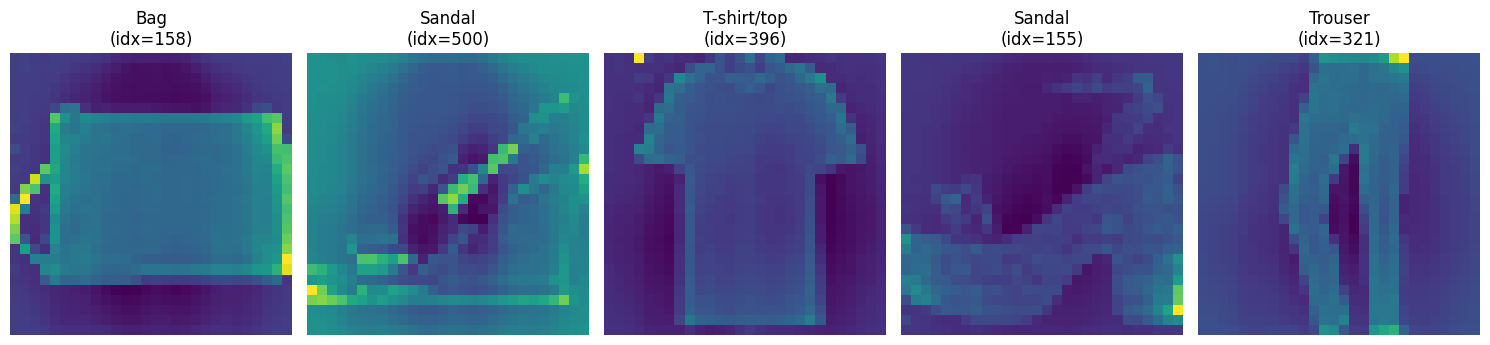

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_show = 5
idxs = np.random.choice(X_train.shape[0], size=n_show, replace=False)

fig, axes = plt.subplots(1, n_show, figsize=(15, 4))
for ax, idx in zip(axes, idxs):
    img = X_train[idx].reshape(28, 28)  # shape (32,32,3), float
    # Recover displayable range: if values are very small (double-normalized), scale up
    if img.max() < 0.01:
        img = img * 255.0
    # Normalize image to [0,1] for safe display (per-image)
    img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    ax.imshow(img)
    ax.set_title(f"{classes_id[int(y_train[idx])]}\n(idx={idx})")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import label_binarize

# Compute class labels and binarized labels once for the entire notebook
set_classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=set_classes)
y_test_bin = label_binarize(y_test, classes=set_classes)

print(f"Number of classes: {len(set_classes)}")
print(f"y_train_bin shape: {y_train_bin.shape}")

Number of classes: 10
y_train_bin shape: (700, 10)


# 2 Baseline implementation

Before starting the implementation of any feature extraction model, we will train two baseline classifiers. These models will serve as a reference to evaluate the advantages and performance improvements later provided by the models incorporating feature extraction.

Implement the following reference classifiers on the features as provided (no extra feature extraction):

*   DummyClassifier (strategy = "most_frequent").

*   Linear SVM with hyperparameter tuning via GridSearchCV for the regularization parameter C.

Evaluate the performance of these models in terms of accuracy.

## SOLUTION 2

In [6]:
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV


# -------- Baseline 1: Dummy (most frequent class) ------------------
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

acc_dummy = dummy.score(X_test, y_test)

print("== Dummy (most frequent class) ==")
print(f"Accuracy: {acc_dummy:.4f}")

# -------- Baseline 2: Linear SVM ----------------------------------
# Train linear SVM and CV parameter C
grid_search_params = {
    'C': [0.1, 1, 10, 100]
}
grid_svm = GridSearchCV(SVC(kernel ='linear'), param_grid=grid_search_params, cv=5)
grid_svm.fit(X_train, y_train)
acc_svm = grid_svm.score(X_test, y_test)


print("== Linear SVM (no feature extraction) ==")
print(f"Accuracy: {acc_svm:.4f}")

== Dummy (most frequent class) ==
Accuracy: 0.1000
== Linear SVM (no feature extraction) ==
Accuracy: 0.7832


# 3. Linear Feature Extraction (PCA / PLS / CCA)

The core objective of this section is to determine if **linear feature extraction techniques** (**PCA**, **PLS**, **CCA**) can **maintain or even surpass** the performance of the *baseline* classifiers (Section 1), while simultaneously achieving a **drastic reduction in dimensionality** from the initial 784 features.

For each linear method (**PCA**, **PLS**, **CCA**), perform the following steps:

## 1. Visualization and Projection Analysis

Begin by projecting the data onto its first two main components (or equivalents) to gain an initial view of the reduced dataset.

* **2D Projection Figure:** Include a **2D projection figure** (plot the projection onto two components for the *train* and *test* sets).
* **Analysis:** Analyze the **behavior of the projected data in *train*** and how the **pattern generalizes to *test*** for each feature extraction technique.

## 2. Feature Extraction + Classification Pipeline 

Next, implement a pipeline that applies a first step of feature reduction/extraction, followed by classification using a **Linear SVM** on the extracted variables.

### 2.1. Efficient Implementation

* **Efficiency:** Design the most efficient implementation for the pipeline. **It is not strictly necessary to use the `Pipeline` function from `scikit-learn`**, but you must ensure the correct sequencing of steps (extraction $\rightarrow$ classification) within the CV process.

### 2.2. Hyperparameter Selection

* **Using CV:** Use Cross-Validation to simultaneously select:
    * The **number of components**.
    * And the regularization parameter $C$ of the SVM classifier.

### 2.3. Leakage-Safe Implementation

* **Safe Procedure:** Build a **data leakage-safe pipeline**. When performing **Cross-Validation (CV)**, the **feature extractor's *fit*** must be computed **only on the training fold** for each iteration.
* **Restriction:** **Do not use test data or test labels** in the training, CV, or hyperparameter selection process.

### 2.4. Expected Issues

*  CCA Performance: You may find that the final model performance using CCA is very poor compared to PCA and PLS. Why do you think the CCA performs so poorly? Remember that CCA solves a generalized eigenvalue and eigenvector problem and think about the implications this can have on this dataset. How do you think this problem can be solved?


## SOLUTION 3

### Some utility functions

### Generic Cross-Validation Pipeline Function

The `cv_feature_extraction_pipeline()` function below provides a reusable, leakage-safe implementation for:

1. **Feature Extraction Methods**: Works with any sklearn-compatible feature extractor (PCA, PLS, CCA, or pipelines like PCA+CCA)
2. **Supervised vs Unsupervised**: Handles both supervised methods (PLS/CCA that use labels) and unsupervised (PCA)
3. **Hyperparameter Tuning**: Jointly optimizes:
   - Number of components to select
   - SVM regularization parameter C
4. **Leakage-Safe CV**: Feature extraction is fit only on training folds, never on validation data
5. **Complete Pipeline**: Returns optimal parameters, CV scores, and test accuracy

**Usage Examples:**
- Linear methods: PLS, CCA with original data
- Kernel approximations: CCA with Nyström or RBF Sampler features
- Combined methods: PCA+CCA pipelines

**Note:** Kernel methods with full kernel matrices (KCCA) require special indexing with `np.ix_()` and use a slightly modified CV loop (see KCCA cells).

In [7]:
def plot_2d_projection(X_train_proj, X_test_proj, y_train, y_test, method_name='Feature Extraction'):
    """
    Plot 2D projections of training and test data side by side.
    
    Parameters:
    -----------
    X_train_proj : array-like, shape (n_train_samples, 2)
        2D projection of training data
    X_test_proj : array-like, shape (n_test_samples, 2)
        2D projection of test data
    y_train : array-like, shape (n_train_samples,)
        Training labels
    y_test : array-like, shape (n_test_samples,)
        Test labels
    method_name : str, default='Feature Extraction'
        Name of the feature extraction method (e.g., 'PCA', 'PLS', 'CCA')
    """
    plt.figure(figsize=(12, 4))
    
    # Training data subplot
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_train_proj[:, 0], X_train_proj[:, 1], c=y_train, cmap='viridis')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title(f'{method_name} - Training Data')
    
    # Test data subplot
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_test_proj[:, 0], X_test_proj[:, 1], c=y_test, cmap='viridis')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title(f'{method_name} - Test Data')
    plt.colorbar(scatter)
    
    plt.tight_layout()
    plt.show()

In [8]:
from sklearn.base import BaseEstimator

class FirstKFeatures(BaseEstimator):
    """
    Scikit-learn compatible transformer that selects the first K columns (features).

    Parameters
    ----------
    K : int
        Number of features to keep in the transformation.

    Usage
    -----
    >>> tr = FirstKFeatures(K=10)
    >>> tr.fit(X)               # does not modify anything in fit
    >>> X_k = tr.transform(X)   # returns X[:, :K] (supports numpy, pandas, sparse)
    """
    def __init__(self, K=10):
        self.K = int(K)

    def fit(self, X, y=None):
        # Does not learn anything; sklearn interface
        return self

    def transform(self, X):
        if X.ndim != 2:
            raise ValueError("Input X must be a 2D matrix (n_samples, n_features).")
        n_features = X.shape[1]
        k = min(self.K, n_features)
        return X[:, :k]

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)

## 4.1 PCA


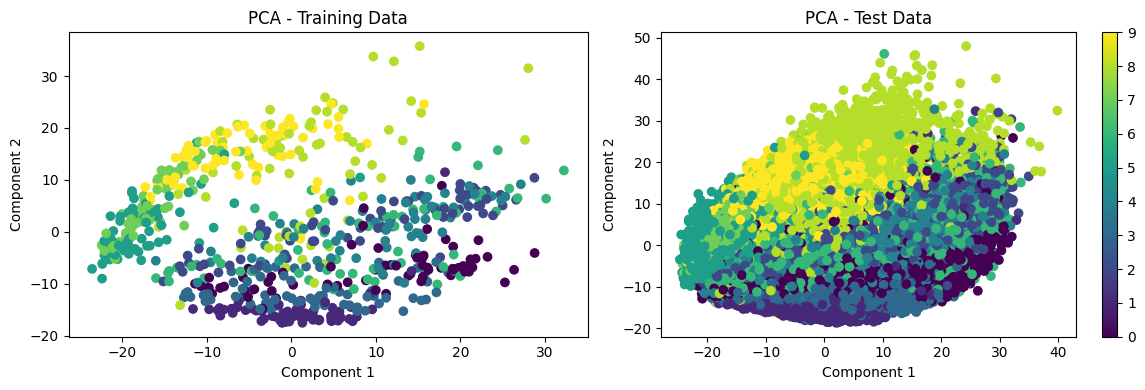

In [9]:
# Compute PCA with 2 components and plot data points

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
X_pca_test = pca.transform(X_test)

# Plot 2D projection
plot_2d_projection(X_pca, X_pca_test, y_train, y_test, method_name='PCA')

In [10]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# PCA (200 comps) + GridSearch over number of PCA components (via FirstKFeatures) and linear SVM C

# 1) Compute PCA with 200 components
pca = PCA(n_components=200)
P_train_FE = pca.fit_transform(X_train)
P_test_FE = pca.transform(X_test)

print(f"PCA-transformed train set shape: {P_train_FE.shape}")

# 2) Pipeline: FirstKFeatures selects the first K PCA components, SVM is linear
pipe = Pipeline([
    ('cols', FirstKFeatures()),        # K will be set by GridSearchCV
    ('clf', LinearSVC())          # SVC class available in the notebook
])

param_grid = {
    'cols__K': [10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200],
    'clf__C' : np.logspace(-2, 2, 5)
}

# 3) Grid search (joint validation of K and C)
grid_PCA_SVM = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_PCA_SVM.fit(P_train_FE, y_train)

# 4) Evaluate on test set
acc_test = grid_PCA_SVM.score(P_test_FE, y_test)

print("Best params:", grid_PCA_SVM.best_params_)
print(f"CV best score: {grid_PCA_SVM.best_score_:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")


PCA-transformed train set shape: (700, 200)
Fitting 5 folds for each of 55 candidates, totalling 275 fits
Best params: {'clf__C': np.float64(0.01), 'cols__K': 75}
CV best score: 0.7843
Test Accuracy: 0.7724


# PLS

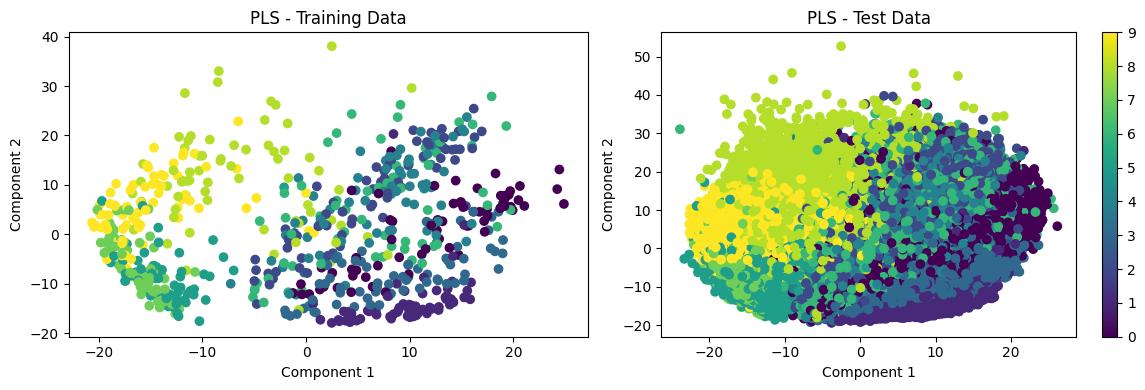

In [11]:
# Compute PLS with 2 components and plot data points

from sklearn.cross_decomposition import PLSSVD
import matplotlib.pyplot as plt

pls = PLSSVD(n_components=2)
X_pls = pls.fit_transform(X_train, y_train_bin)[0]
X_pls_test = pls.transform(X_test)

# Plot 2D projection
plot_2d_projection(X_pls, X_pls_test, y_train, y_test, method_name='PLS')

In [12]:
### IMPLEMENTATION WITHOUT LEAKAGE

from sklearn.model_selection import KFold
from sklearn.cross_decomposition import PLSSVD
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

FE = PLSSVD(n_components=len(np.unique(y_train))-1)

pipe = Pipeline([
    ('cols', FirstKFeatures()),        # K will be set by GridSearchCV
    ('clf', LinearSVC())          # SVC class available in the notebook
])

param_grid = {
    'cols__K': range(2, len(np.unique(y_train))),  # Number of components to select
    'clf__C': np.logspace(-2, 2, 5)
}
param_combinations = list(ParameterGrid(param_grid))

# Parameters
nfold = 10
N_tr, N_dim = X_train.shape
range_k = range(1, len(np.unique(y_train)))

# Create data partitions (check the structure of folds)
skf = KFold(n_splits=nfold)

# Create variable (acc_val) to save the validation results
acc_val = np.zeros((nfold, len(param_combinations)))

for f, (train, val) in enumerate(skf.split(X_train, y_train)):
    # f is an index with the number of fold
    # train has the training data positions for fold f
    # val has the validation data positions for fold f

    # Create training and validation partitions for fold f
    X_tr_f = X_train[train, :]
    Y_tr_f = y_train[train]
    Y_tr_bin_f = y_train_bin[train,:]
    X_val_f = X_train[val, :]
    Y_val_f = y_train[val]
    Y_val_bin_f = y_train_bin[val,:]

    # Compute PLS components for fold f
    P_train_FE, _ =  FE.fit_transform(X_tr_f, Y_tr_bin_f)
    P_val_FE = FE.transform(X_val_f)

    for i, params in enumerate(param_combinations):
        pipe.set_params(**params)
        pipe.fit(P_train_FE, Y_tr_f)
        acc_val[f, i] = pipe.score(P_val_FE,Y_val_f)
        

# Compute the average validation acc (average over the different folds)
acc_val_med = np.mean(acc_val, axis=0)
pos_val = np.argmax(acc_val_med)
# Optimal parameters
Num_feat_opt = param_combinations[pos_val]['cols__K']
print('Number of selected features by CV is %d'%(Num_feat_opt ))    
C_opt = param_combinations[pos_val]['clf__C']
print('Optimal C by CV is %2.3f'%(C_opt ))

# Final model
FE.set_params(n_components=Num_feat_opt)
FE.fit(X_train, y_train_bin)
P_train_FE = FE.transform(X_train)
P_test_FE = FE.transform(X_test)

linSVM = LinearSVC(C=C_opt).fit(P_train_FE, y_train)
acc_test = linSVM.score(P_test_FE, y_test)

print('Test accuracy is %2.2f' %(acc_test))
#</SOL>

Number of selected features by CV is 9
Optimal C by CV is 0.100
Test accuracy is 0.75


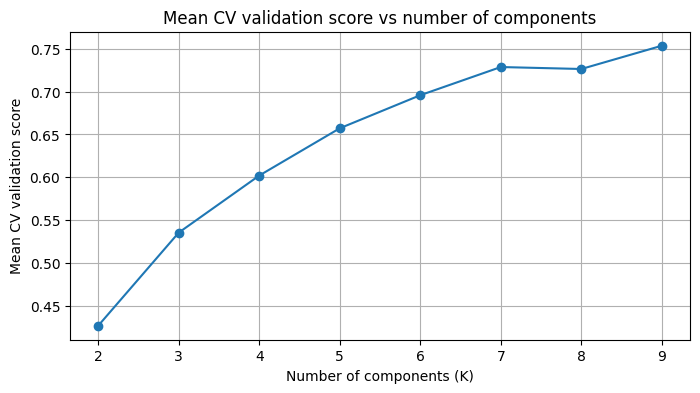

In [13]:
# Plot acc_val_med vs number of components (K).
# Expects acc_val_med to be defined (1D array) and param_combinations to be a list
# of dicts containing 'cols__K'. If acc_val_med is already keyed by K, it will handle that too.

acc = np.asarray(acc_val_med)

Ks = np.array([p['cols__K'] for p in param_combinations])
unique_K = np.sort(np.unique(Ks))
mean_scores = [acc[Ks == k].mean() for k in unique_K]

plt.figure(figsize=(8,4))
plt.plot(unique_K, mean_scores, marker='o')
plt.xlabel('Number of components (K)')
plt.ylabel('Mean CV validation score')
plt.title('Mean CV validation score vs number of components')
plt.grid(True)
plt.show()

In [14]:
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Design custom function for CV feature extraction + SVM pipeline

def cv_feature_extraction_pipeline(
    X_train, y_train, y_train_bin, X_test, y_test,
    feature_extractor, 
    param_grid=None,
    nfold=10,
    use_labels_in_fe=True,
    verbose=True
):
    """
    Generic cross-validation pipeline for feature extraction + Linear SVM classification.
    
    This function handles the complete CV workflow including:
    - Leakage-safe feature extraction (fit only on train folds)
    - Hyperparameter selection for both FE and classifier
    - Final model training and evaluation
    
    Parameters:
    -----------
    X_train : array-like, shape (n_samples, n_features)
        Training data
    y_train : array-like, shape (n_samples,)
        Training labels (class labels)
    y_train_bin : array-like, shape (n_samples, n_classes)
        Binarized training labels (for supervised FE methods like PLS/CCA)
    X_test : array-like, shape (n_test_samples, n_features)
        Test data
    y_test : array-like, shape (n_test_samples,)
        Test labels
    feature_extractor : sklearn estimator
        Feature extraction method (e.g., PCA, PLSSVD, CCA, or Pipeline with PCA+CCA)
        Must have fit_transform and transform methods
    param_grid : dict, optional
        Grid of hyperparameters to search. Default searches number of components and C.
        Example: {'cols__K': range(2, 10), 'clf__C': np.logspace(-2, 2, 5)}
    nfold : int, default=10
        Number of cross-validation folds
    use_labels_in_fe : bool, default=True
        Whether the feature extractor uses labels (True for PLS/CCA, False for PCA)
    verbose : bool, default=True
        Whether to print results
        
    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'best_K': optimal number of components
        - 'best_C': optimal SVM regularization parameter
        - 'cv_score': best cross-validation score
        - 'test_accuracy': accuracy on test set
        - 'acc_val': validation accuracies for all folds and parameter combinations
        - 'acc_val_mean': mean validation accuracy across folds
    """

    if param_grid is None:
        param_grid = {
            'cols__K': range(2, len(np.unique(y_train))),
            'clf__C': np.logspace(-2, 2, 5)
        }
    param_combinations = list(ParameterGrid(param_grid))
    pipe = Pipeline([
        ('cols', FirstKFeatures()),
        ('clf', LinearSVC())
    ])
    skf = KFold(n_splits=nfold)
    acc_val = np.zeros((nfold, len(param_combinations)))
    for f, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr_f = X_train[train_idx, :]
        Y_tr_f = y_train[train_idx]
        Y_tr_bin_f = y_train_bin[train_idx, :]
        X_val_f = X_train[val_idx, :]
        Y_val_f = y_train[val_idx]
        Y_val_bin_f = y_train_bin[val_idx, :]
        if use_labels_in_fe:
            if hasattr(feature_extractor, 'fit_transform'):
                P_train_FE, _ = feature_extractor.fit_transform(X_tr_f, Y_tr_bin_f)
            else:
                feature_extractor.fit(X_tr_f, Y_tr_bin_f)
                P_train_FE = feature_extractor.transform(X_tr_f)
        else:
            P_train_FE = feature_extractor.fit_transform(X_tr_f)
        P_val_FE = feature_extractor.transform(X_val_f)
        for i, params in enumerate(param_combinations):
            pipe.set_params(**params)
            pipe.fit(P_train_FE, Y_tr_f)
            acc_val[f, i] = pipe.score(P_val_FE, Y_val_f)
    acc_val_mean = np.mean(acc_val, axis=0)
    pos_val = np.argmax(acc_val_mean)
    best_params = param_combinations[pos_val]
    Num_feat_opt = best_params['cols__K']
    C_opt = best_params['clf__C']
    best_cv_score = acc_val_mean[pos_val]
    if verbose:
        print('Number of selected features by CV is %d' % Num_feat_opt)
        print('Optimal C by CV is %.3f' % C_opt)
        print('Best CV score: %.4f' % best_cv_score)
    # --- n_components assignment ---
    if isinstance(feature_extractor, Pipeline):
        feature_extractor.set_params(cca__n_components=Num_feat_opt)
    else:
        feature_extractor.set_params(n_components=Num_feat_opt)
    if use_labels_in_fe:
        feature_extractor.fit(X_train, y_train_bin)
    else:
        feature_extractor.fit(X_train)
    P_train_FE = feature_extractor.transform(X_train)
    P_test_FE = feature_extractor.transform(X_test)
    linSVM = LinearSVC(C=C_opt).fit(P_train_FE, y_train)
    acc_test = linSVM.score(P_test_FE, y_test)
    if verbose:
        print('Test accuracy is %.2f' % acc_test)
    return {
        'best_K': Num_feat_opt,
        'best_C': C_opt,
        'cv_score': best_cv_score,
        'test_accuracy': acc_test,
        'acc_val': acc_val,
        'acc_val_mean': acc_val_mean,
        'param_combinations': param_combinations
    }


In [15]:
from sklearn.cross_decomposition import PLSSVD

FE = PLSSVD(n_components=len(np.unique(y_train))-1)

results = cv_feature_extraction_pipeline(
    X_train, y_train, y_train_bin, X_test, y_test,
    feature_extractor=FE,
    use_labels_in_fe=True,  # True for PLS/CCA, False for PCA
    verbose=True
)

Number of selected features by CV is 9
Optimal C by CV is 0.100
Best CV score: 0.7571
Test accuracy is 0.75


## CCA

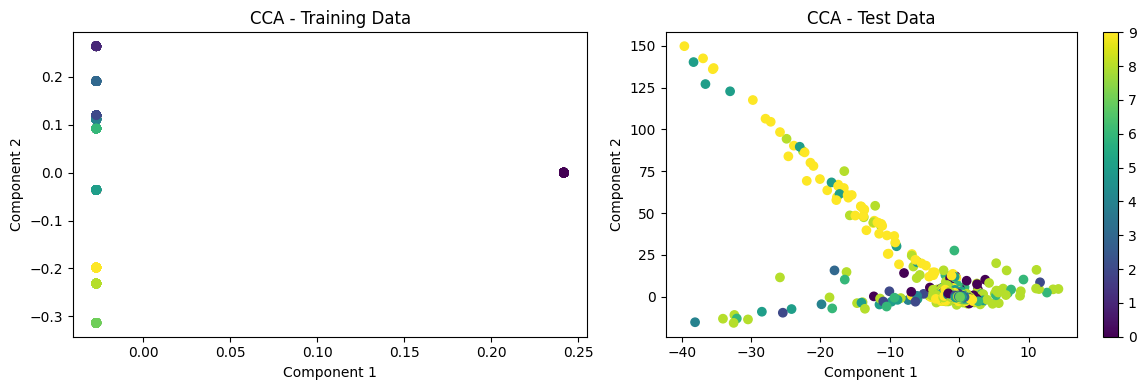

In [16]:
# Compute CCA with 2 components and plot data points
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=2)
X_cca = cca.fit_transform(X_train, y_train_bin)[0]
# Transform test data
X_cca_test = cca.transform(X_test)

# Plot 2D projection
plot_2d_projection(X_cca, X_cca_test, y_train, y_test, method_name='CCA')

In [17]:
# Compute empirical covariance Cxx and report ranks (uses X_train already defined)
X = X_train  # existing variable
n, d = X.shape

rank_Xc = np.linalg.matrix_rank(X)

# SVD of centered data -> singular values and implied eigenvalues of Cxx
sv = np.linalg.svd(X, compute_uv=False)
evals = (sv**2) / (n - 1)

# Effective rank for default tolerance used by numpy.linalg.matrix_rank
eps = np.finfo(float).eps
tol_default = sv.max() * max(X.shape) * eps
rank_tol_default = np.sum(evals > tol_default)

print(f"rank(centered data Xc): {rank_Xc}")
print(f"tol (default used in matrix_rank): {tol_default:.3e}")
print(f"rank by eigenvalue threshold > tol: {rank_tol_default}")
print("Top 10 eigenvalues of Cxx:", np.round(evals[:10], 6))
print("Smallest 10 eigenvalues of Cxx:", np.round(evals[-10:], 6))

rank(centered data Xc): 699
tol (default used in matrix_rank): 5.961e-11
rank by eigenvalue threshold > tol: 699
Top 10 eigenvalues of Cxx: [167.7414   118.447495  45.382805  41.03882   34.948204  25.567284
  23.651997  16.715841  14.438831  11.564919]
Smallest 10 eigenvalues of Cxx: [1.04e-04 9.20e-05 9.10e-05 8.40e-05 7.60e-05 6.00e-05 5.40e-05 4.80e-05
 4.50e-05 0.00e+00]


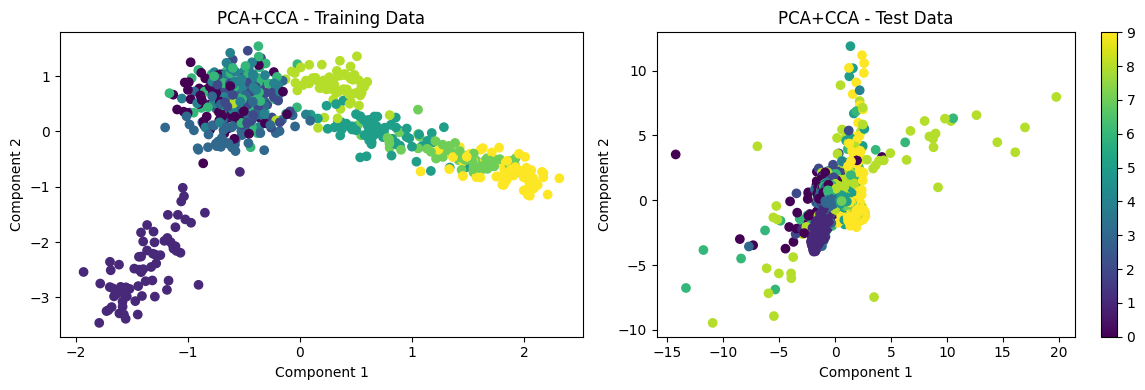

In [18]:
# Compute PCA + CCA with 2 components and plot data points

from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt

N_pca = 100
pca_cca = Pipeline([
    ('pca', PCA(n_components=N_pca)),
    ('cca', CCA(n_components=2))
])

X_pca_cca = pca_cca.fit_transform(X_train, y_train_bin)[0]
# Transform test data
X_pca_cca_test = pca_cca.transform(X_test)

# Plot 2D projection
plot_2d_projection(X_pca_cca, X_pca_cca_test, y_train, y_test, method_name='PCA+CCA')

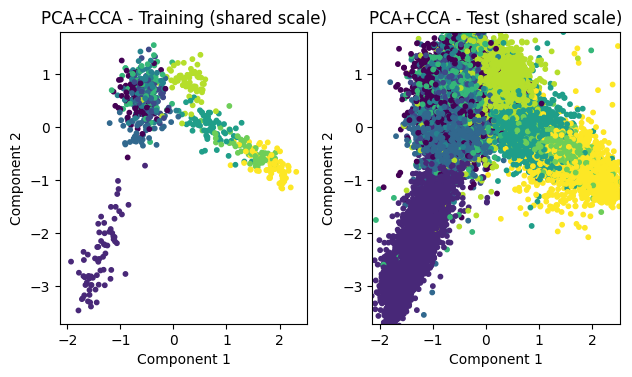

In [19]:
import numpy as np

# Re-draw PCA+CCA forcing identical axis scaling for train and test projections

import matplotlib.pyplot as plt

# Ensure projections exist (compute if not)
try:
    X_pca_cca, X_pca_cca_test
except NameError:
    X_pca_cca = pca_cca.fit_transform(X_train, y_train_bin)[0]
    X_pca_cca_test = pca_cca.transform(X_test)

# force Xtrain scale
xs = X_pca_cca[:, 0]
ys = X_pca_cca[:, 1]
x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

# Add small margin
x_pad = 0.05 * (x_max - x_min) if (x_max - x_min) != 0 else 1.0
y_pad = 0.05 * (y_max - y_min) if (y_max - y_min) != 0 else 1.0
x_lim = (x_min - x_pad, x_max + x_pad)
y_lim = (y_min - y_pad, y_max + y_pad)

fig, axes = plt.subplots(1, 2)

cmap = 'viridis'
vmin, vmax = 0, len(set_classes) - 1

# Training plot
sc0 = axes[0].scatter(X_pca_cca[:, 0], X_pca_cca[:, 1], c=y_train, cmap=cmap, vmin=vmin, vmax=vmax, s=10)
axes[0].set_title('PCA+CCA - Training (shared scale)')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].set_xlim(x_lim)
axes[0].set_ylim(y_lim)
axes[0].set_aspect('equal', adjustable='box')

# Test plot
sc1 = axes[1].scatter(X_pca_cca_test[:, 0], X_pca_cca_test[:, 1], c=y_test, cmap=cmap, vmin=vmin, vmax=vmax, s=10)
axes[1].set_title('PCA+CCA - Test (shared scale)')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
axes[1].set_xlim(x_lim)
axes[1].set_ylim(y_lim)
axes[1].set_aspect('equal', adjustable='box')

# Single colorbar
#cbar = fig.colorbar(sc0, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
#cbar.set_label('class label')

plt.tight_layout()
plt.show()

In [34]:
from sklearn.cross_decomposition import CCA
from sklearn.pipeline import Pipeline

# Feature extractor: PCA + CCA
FE = Pipeline([
    ('pca', PCA(n_components=N_pca)),
    ('cca', CCA(n_components=len(np.unique(y_train))-1))
])

# Custom parameter grid for PCA+CCA
param_grid = {
    'cols__K': range(2, len(np.unique(y_train))),
    'clf__C': np.logspace(-1, 3, 5)
}

# Run CV pipeline
results = cv_feature_extraction_pipeline(
    X_train, y_train, y_train_bin, X_test, y_test,
    feature_extractor=FE,
    param_grid=param_grid,
    use_labels_in_fe=True,
    verbose=True
)

# Store results for later analysis
acc_val_med = results['acc_val_mean']
param_combinations = results['param_combinations']

# Note: The function uses n_components for setting the number of features,
# but for nested pipelines like PCA+CCA, you may need to manually adjust
# the inner CCA n_components if needed for the final model

Number of selected features by CV is 9
Optimal C by CV is 1.000
Best CV score: 0.7743
Test accuracy is 0.78


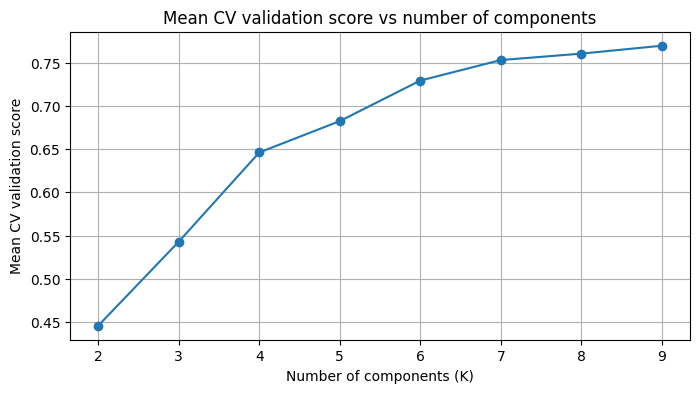

In [21]:
import numpy as np

# Plot acc_val_med vs number of components (K).
# Expects acc_val_med to be defined (1D array) and param_combinations to be a list
# of dicts containing 'cols__K'. If acc_val_med is already keyed by K, it will handle that too.

import matplotlib.pyplot as plt


acc = np.asarray(acc_val_med)

Ks = np.array([p['cols__K'] for p in param_combinations])
unique_K = np.sort(np.unique(Ks))
mean_scores = [acc[Ks == k].mean() for k in unique_K]

plt.figure(figsize=(8,4))
plt.plot(unique_K, mean_scores, marker='o')
plt.xlabel('Number of components (K)')
plt.ylabel('Mean CV validation score')
plt.title('Mean CV validation score vs number of components')
plt.grid(True)
plt.show()

In [22]:
# we can also select the PCA components with CV!!!!!

# Feature extractor: PCA + CCA
myPCA = PCA(n_components=450)
myCCA = CCA(n_components=len(np.unique(y_train))-1)

PCA_K_range = [50, 75, 100, 200, 400]

pipe = Pipeline([
    ('cols', FirstKFeatures()),        # K will be set by GridSearchCV
    ('clf', LinearSVC())          # SVC class available in the notebook
])

param_grid = {
    'cols__K': range(2, len(np.unique(y_train))),  # Number of components to select
    'clf__C': np.logspace(-1, 3, 5)
}
param_combinations = list(ParameterGrid(param_grid))


# Parameters
nfold = 10
N_tr, N_dim = X_train.shape

# Create data partitions (check the structure of folds)
skf = KFold(n_splits=nfold)

# Create variable (acc_val) to save the validation results
acc_val = np.zeros((nfold, len(PCA_K_range),len(param_combinations)))


# PCA can be computed with all traning data at begingin (we don't use labels)
X_train_pca = myPCA.fit_transform(X_train)
X_test_pca = myPCA.transform(X_test)

for f, (train, val) in enumerate(skf.split(X_train, y_train)):
    # f is an index with the number of fold
    # train has the training data positions for fold f
    # val has the validation data positions for fold f

    # Create training and validation partitions for fold f
    X_tr_f = X_train_pca[train, :]
    Y_tr_f = y_train[train]
    Y_tr_bin_f = y_train_bin[train,:]
    X_val_f = X_train_pca[val, :]
    Y_val_f = y_train[val]
    Y_val_bin_f = y_train_bin[val,:]

    for k, PCA_K in enumerate(PCA_K_range): 
        # Compute PCA+CCA components for fold f
        myCCA.fit(X_tr_f[:, :PCA_K], Y_tr_bin_f)
        P_train_FE = myCCA.transform(X_tr_f[:, :PCA_K])
        P_val_FE = myCCA.transform(X_val_f[:, :PCA_K])

        for i, params in enumerate(param_combinations):
            pipe.set_params(**params)
            pipe.fit(P_train_FE, Y_tr_f)
            acc_val[f, k, i] = pipe.score(P_val_FE,Y_val_f)
        
# Compute the average validation acc (average over the different folds)
acc_val_med = np.mean(acc_val, axis=0)
pos_val = np.argmax(acc_val_med)

# tupla (fila, columna) en la matriz 2D
pos_val_K, pos_val_params = np.unravel_index(pos_val, acc_val_med.shape)

# Optimal parameters
PCA_K_opt = PCA_K_range[pos_val_K]
print('Number of components of the PCA is %d'%(PCA_K_opt))
Num_feat_opt = param_combinations[pos_val_params]['cols__K']
print('Number of selected features by CV is %d'%(Num_feat_opt ))    
C_opt = param_combinations[pos_val_params]['clf__C']
print('Optimal C by CV is %2.3f'%(C_opt ))

# Final model
myCCA.set_params(n_components=Num_feat_opt)
myCCA.fit(X_train_pca[:,:PCA_K_opt], y_train_bin)
P_train_FE = myCCA.transform(X_train_pca[:,:PCA_K_opt])
P_test_FE = myCCA.transform(X_test_pca[:,:PCA_K_opt])

linSVM = LinearSVC(C=C_opt).fit(P_train_FE, y_train)
acc_test = linSVM.score(P_test_FE, y_test)

print('Test accuracy is %2.2f' %(acc_test))
#</SOL>


Number of components of the PCA is 75
Number of selected features by CV is 9
Optimal C by CV is 10.000
Test accuracy is 0.78


# 4. Kernel Feature Extraction 

This section explores the non-linear capabilities of feature extraction methods by using **Kernel versions**, focusing on maintaining a leakage-safe pipeline and analyzing the trade-offs in computational cost. To simplify this section, here we will only focus on the CCA algorithm.

## 4.1. Kernel CCA (KCCA) with Linear SVM Evaluation

You will implement the Kernel version of CCA (KCCA), combining it with a Linear SVM classifier.

* **Implementation:** Build a leakage-safe pipeline: **KCCA $\rightarrow$ Linear SVM**.
* **Parameter Simplification:** To simplify the joint Cross-Validation (CV) process, fix the $\gamma$ parameter for the KCCA kernel (e.g., RBF kernel) using the common heuristic $\gamma = 1 / D$, where $D$ is the number of features (784).
* **Centering kernel matrix**: don't forget to center the kernel matrix.
* **Check the ill-conditioned problems in the KCCA**
* **Joint CV:** Use CV to select the optimal **number of components** (for KCCA) and the SVM regularization parameter **$C$**.
* **Evaluation:** Evaluate the final model on the held-out test set. 
* **Discussion:** Discuss why the standard Kernel approach (even with a Linear SVM on the projected features) results in a **non-sparse model** (i.e., a model whose prediction speed depends linearly on the entire training set or the number of components/support vectors).


In [23]:
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

# Precompute kernel matrix
D = X_train.shape[1]
# gamma = 1 / D (D = number of features)
gamma = 1 / D

# Compute RBF kernels (train-train and test-train)
K_train = rbf_kernel(X_train, gamma=gamma)
K_test = rbf_kernel(X_test, X_train, gamma=gamma)

print(f"gamma={gamma:.6e}")
print(f"K_train: shape={K_train.shape}, dtype={K_train.dtype}")
print(f"K_test: shape={K_test.shape}, dtype={K_test.dtype}")

gamma=1.275510e-03
K_train: shape=(700, 700), dtype=float32
K_test: shape=(59300, 700), dtype=float32


In [24]:
# Center kernel matrix
def center_K(K):
    """Center a kernel matrix K, i.e., removes the data mean in the feature space.

    Args:
        K: kernel matrix
    """
    size_1,size_2 = K.shape
    D1 = K.sum(axis=0)/size_1
    D2 = K.sum(axis=1)/size_2
    E = D2.sum(axis=0)/size_1

    K_n = K + np.tile(E,[size_1,size_2]) - np.tile(D1,[size_1,1]) - np.tile(D2,[size_2,1]).T
    return K_n


# Center the kernel matrix
K_train = center_K(K_train)
K_test = center_K(K_test)

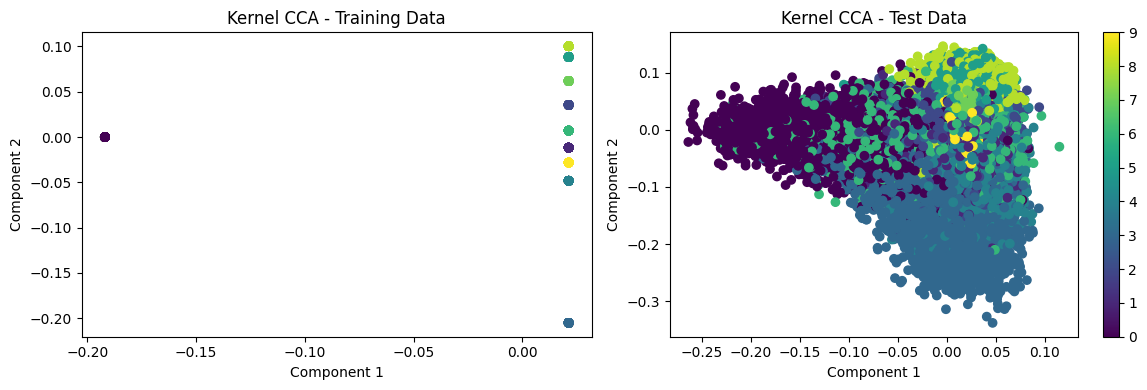

In [25]:
from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt

cca = CCA(n_components=2)
K_cca = cca.fit_transform(K_train, y_train_bin)[0]
# Transform test data
K_cca_test = cca.transform(K_test)

# Plot 2D projection
plot_2d_projection(K_cca, K_cca_test, y_train, y_test, method_name='Kernel CCA')

In [26]:
# Compute empirical covariance Cxx and report ranks (uses X_train already defined)
X = K_train  # existing variable
n, p = X.shape
rank_Xc = np.linalg.matrix_rank(X)

# SVD of centered data -> singular values and implied eigenvalues of Cxx
sv = np.linalg.svd(X, compute_uv=False)
evals = (sv**2) / (n - 1)

# Effective rank for default tolerance used by numpy.linalg.matrix_rank
eps = np.finfo(float).eps
tol_default = sv.max() * max(X.shape) * eps
rank_tol_default = np.sum(evals > tol_default)

print(f"rank(centered data Xc): {rank_Xc}")
print(f"tol (default used in matrix_rank): {tol_default:.3e}")
print(f"rank by eigenvalue threshold > tol: {rank_tol_default}")
print("Top 10 eigenvalues of Cxx:", np.round(evals[:10], 6))
print("Smallest 10 eigenvalues of Cxx:", np.round(evals[-10:], 6))

rank(centered data Xc): 699
tol (default used in matrix_rank): 8.754e-12
rank by eigenvalue threshold > tol: 699
Top 10 eigenvalues of Cxx: [4.538397 3.083304 1.076777 0.403092 0.341454 0.325653 0.158858 0.102652
 0.082016 0.0554  ]
Smallest 10 eigenvalues of Cxx: [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 0.e+00 0.e+00]


In [27]:
### Kernel CCA implementation using generic CV pipeline

from sklearn.cross_decomposition import CCA

# Create CCA feature extractor
FE = CCA(n_components=len(np.unique(y_train))-1)

# Custom parameter grid for KCCA
param_grid = {
    'cols__K': range(2, len(np.unique(y_train))),
    'clf__C': np.logspace(-1, 3, 5)
}

# Note: For kernel methods, we need a custom CV loop because kernel matrices
# require special indexing with np.ix_. We'll create a wrapper for this.
pipe = Pipeline([
    ('cols', FirstKFeatures()),
    ('clf', LinearSVC())
])

param_combinations = list(ParameterGrid(param_grid))
nfold = 10
skf = KFold(n_splits=nfold)
acc_val = np.zeros((nfold, len(param_combinations)))

for f, (train, val) in enumerate(skf.split(X_train, y_train)):
    # Special kernel matrix indexing with np.ix_
    K_tr_f = K_train[np.ix_(train, train)]
    Y_tr_f = y_train[train]
    Y_tr_bin_f = y_train_bin[train, :]
    K_val_f = K_train[np.ix_(val, train)]
    Y_val_f = y_train[val]
    
    # Compute KCCA components for fold f
    P_train_FE, _ = FE.fit_transform(K_tr_f, Y_tr_bin_f)
    P_val_FE = FE.transform(K_val_f)
    
    for i, params in enumerate(param_combinations):
        pipe.set_params(**params)
        pipe.fit(P_train_FE, Y_tr_f)
        acc_val[f, i] = pipe.score(P_val_FE, Y_val_f)

# Find best parameters
acc_val_med = np.mean(acc_val, axis=0)
pos_val = np.argmax(acc_val_med)
Num_feat_opt = param_combinations[pos_val]['cols__K']
C_opt = param_combinations[pos_val]['clf__C']

print('Number of selected features by CV is %d' % Num_feat_opt)
print('Optimal C by CV is %.3f' % C_opt)

# Train final model
FE.set_params(n_components=Num_feat_opt)
FE.fit(K_train, y_train_bin)
P_train_FE = FE.transform(K_train)
P_test_FE = FE.transform(K_test)

linSVM = LinearSVC(C=C_opt).fit(P_train_FE, y_train)
acc_test = linSVM.score(P_test_FE, y_test)

print('Test accuracy is %.2f' % acc_test)

Number of selected features by CV is 9
Optimal C by CV is 1.000
Test accuracy is 0.80


This is just an example (it is not requested) to show the CV of gamma

In [28]:
### Kernel CCA implementation with CV of gamma

FE = CCA(n_components=len(np.unique(y_train))-1)

pipe = Pipeline([
    ('cols', FirstKFeatures()),        # K will be set by GridSearchCV
    ('clf', LinearSVC())          # SVC class available in the notebook
])

param_grid = {
    'cols__K': range(2, len(np.unique(y_train))),  # Number of components to select
    'clf__C': np.logspace(-1, 3, 5)
}
param_combinations = list(ParameterGrid(param_grid))

# Parameters
nfold = 10
N_tr, N_dim = X_train.shape
range_k = range(1, len(np.unique(y_train)))
range_gamma = np.logspace(-2, 2, 5)/D  

# Create data partitions (check the structure of folds)
skf = KFold(n_splits=nfold)

# Create variable (acc_val) to save the validation results
acc_val = np.zeros((len(range_gamma), nfold, len(param_combinations)))

for gg, gamma in enumerate(range_gamma):
    # Precompute kernel matrix
    # Compute RBF kernels (train-train and test-train)
    K_train = rbf_kernel(X_train, gamma=gamma)
    K_test = rbf_kernel(X_test, X_train, gamma=gamma)

    # Center the kernel matrix
    K_train = center_K(K_train)
    K_test = center_K(K_test)

    for f, (train, val) in enumerate(skf.split(X_train, y_train)):
        # f is an index with the number of fold
        # train has the training data positions for fold f
        # val has the validation data positions for fold f

        # Create training and validation partitions for fold f
        K_tr_f = K_train[np.ix_(train, train)] # Take care of indexing!!!!
        Y_tr_f = y_train[train]
        Y_tr_bin_f = y_train_bin[train,:]
        K_val_f = K_train[np.ix_(val, train)]  # Take care of indexing!!!!
        Y_val_f = y_train[val]
        Y_val_bin_f = y_train_bin[val,:]

        # Compute KCCA components for fold f
        P_train_FE, _ =  FE.fit_transform(K_tr_f, Y_tr_bin_f)
        P_val_FE = FE.transform(K_val_f)

        for i, params in enumerate(param_combinations):
            pipe.set_params(**params)
            pipe.fit(P_train_FE, Y_tr_f)
            acc_val[gg, f, i] = pipe.score(P_val_FE,Y_val_f)
        

# Compute the average validation acc (average over the different folds)
acc_val_med = np.mean(acc_val, axis=1)
# Now acc_val_med has shape (len(range_gamma), len(param_combinations))
pos_val = np.unravel_index(np.argmax(acc_val_med), acc_val_med.shape)
# Optimal parameters
gamma_opt = range_gamma[pos_val[0]]
print('Optimal gamma by CV is %2.6f'%(gamma_opt ))
Num_feat_opt = param_combinations[pos_val[1]]['cols__K']
print('Number of selected features by CV is %d'%(Num_feat_opt ))    
C_opt = param_combinations[pos_val[1]]['clf__C']
print('Optimal C by CV is %2.3f'%(C_opt ))  

# Final model
# Compute RBF kernels (train-train and test-train)
K_train = rbf_kernel(X_train, gamma=gamma_opt)
K_test = rbf_kernel(X_test, X_train, gamma=gamma_opt)

# Center the kernel matrix
K_train = center_K(K_train)
K_test = center_K(K_test)

FE.set_params(n_components=Num_feat_opt)
FE.fit(K_train, y_train_bin)
P_train_FE = FE.transform(K_train)
P_test_FE = FE.transform(K_test)

linSVM = LinearSVC(C=C_opt).fit(P_train_FE, y_train)
acc_test = linSVM.score(P_test_FE, y_test)

print('Test accuracy is %2.2f' %(acc_test))

Optimal gamma by CV is 0.001276
Number of selected features by CV is 9
Optimal C by CV is 10.000
Test accuracy is 0.80


## 4.2 — Approximating Kernel Methods 

Kernel methods are often computationally expensive and do not scale well. Note that computing full KCCA requires:

* computing the full kernel matrices $K_x$ and $K_y$,
* centering them,
* solving an eigenvalue problem of size $N \times N$.

This becomes expensive when $N$ is large. Thus, in this section, we will explores two techniques to create *sparse* or *approximated* kernel models to improve efficiency, especially in the test stage.

### 4.2.1 Nyström Approximation

In this section, you will re-implement the **KCCA + Linear SVM** pipeline using the **Nyström method** to approximate the RBF kernel matrix. This approximation drastically reduces computational cost while keeping good accuracy.

Nyström avoids the cost of computing the full RBF kernel matrix by:

1. **Selecting (m) landmark points** from the training set (with $m \ll N$).
2. **Computing only:**

   * $\mathbf{C}$: kernel between all samples and the $m$ landmarks (size $N \times m$).
   * $\mathbf{W}$: kernel among the $m$ landmarks (size $m \times m$).
3. Constructing the **approximation**:
   $$
   \mathbf{K} \approx \mathbf{C} \mathbf{W}^{-1} \mathbf{C}^T.
   $$

This achieves a **rank-(m)** approximation of $\mathbf{K}$, much cheaper to compute and store. Besides, since 
   $$
   \mathbf{K} \approx \mathbf{C} W^{-1/2} (W^{-1/2} \mathbf{C})^T.
   $$
Nyström finds a low-dimensional feature map $\Phi(x) \in \mathbb{R}^{m}$, such that $\Phi(X) = \mathbf{C} W^{-1/2}$, i.e., 
$$
k(x_i, x_j) \approx \langle \Phi(x_i), \Phi(x_j) \rangle.
$$

Thus, instead of working with kernels, we can directly work with **explicit features**.


## Implementation of Nyström in sklearn

Scikit-learn provides the class `sklearn.kernel_approximation.Nystroem`. This transformer receives raw data `X` and computes a **Nyström feature map**:
* Internally selects (m = n_components) landmark points.
* Computes an orthonormalized version of $\mathbf{C} W^{-1/2}$.
* Returns the feature matrix:
  $$
  \mathbf{Z} = \Phi_{\text{Nystroem}}(X) \in \mathbb{R}^{N \times m}.
  $$

This matrix $\mathbf{Z}$ satisfies, approximately $K \approx Z Z^T$.

Then, you can feed $Z$ into:

* **KCCA (linear version)** → because the kernel is now explicit
* **Linear SVM** → cheap at test time

This converts the entire kernel pipeline into a **linear pipeline in the Nyström feature space**.



## Exercise

Use the Nyström approximation to build an efficient implementation of the Kernel CCA + Linear SVM pipeline. Evaluate its performance in terms of accuracy and computational time for different numbers of landmark points (e.g., 100, 200, …, 500), setting the RBF kernel parameter `gamma`to $1/D$, where $D$ is the input dimensionality.

Finally, compare the results with those obtained using the full Kernel CCA implementation.

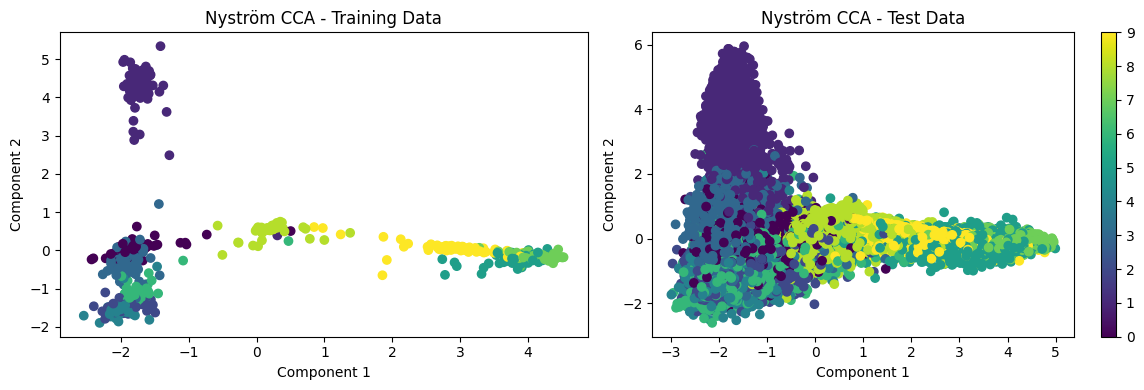

In [29]:
from sklearn.kernel_approximation import Nystroem
from sklearn.preprocessing import StandardScaler

gamma = 1 / D
n_components = 500  
feature_map = Nystroem(kernel='rbf',
                       gamma=gamma,
                       n_components=n_components,
                       random_state=0)

Z_train = feature_map.fit_transform(X_train)  # (N_tr, n_components)
Z_test  = feature_map.transform(X_test)       # (N_te, n_components)

scaler_X = StandardScaler()

Z_train = scaler_X.fit_transform(Z_train)
Z_test = scaler_X.transform(Z_test)

# Compute CCA with 2 components and plot data points
cca = CCA(n_components=2)
X_cca = cca.fit_transform(Z_train, y_train_bin)[0]
# Transform test data
X_cca_test = cca.transform(Z_test)

# Plot 2D projection
plot_2d_projection(X_cca, X_cca_test, y_train, y_test, method_name='Nyström CCA')

In [30]:
from sklearn.cross_decomposition import CCA

# Create CCA feature extractor for Nyström features
FE = CCA(n_components=len(np.unique(y_train))-1)

# Run CV pipeline on Nyström-transformed features
results = cv_feature_extraction_pipeline(
    Z_train, y_train, y_train_bin, Z_test, y_test,
    feature_extractor=FE,
    use_labels_in_fe=True,
    verbose=True
)

# Store results for later analysis
acc_val_med = results['acc_val_mean']
param_combinations = results['param_combinations']

Number of selected features by CV is 9
Optimal C by CV is 0.010
Best CV score: 0.5614
Test accuracy is 0.79



== Nyström n_components = 100 | iter 1/5 ==

== Nyström n_components = 100 | iter 2/5 ==

== Nyström n_components = 100 | iter 3/5 ==

== Nyström n_components = 100 | iter 4/5 ==

== Nyström n_components = 100 | iter 5/5 ==

== Nyström n_components = 200 | iter 1/5 ==

== Nyström n_components = 200 | iter 2/5 ==

== Nyström n_components = 200 | iter 3/5 ==

== Nyström n_components = 200 | iter 4/5 ==

== Nyström n_components = 200 | iter 5/5 ==

== Nyström n_components = 300 | iter 1/5 ==

== Nyström n_components = 300 | iter 2/5 ==

== Nyström n_components = 300 | iter 3/5 ==

== Nyström n_components = 300 | iter 4/5 ==

== Nyström n_components = 300 | iter 5/5 ==

== Nyström n_components = 400 | iter 1/5 ==

== Nyström n_components = 400 | iter 2/5 ==

== Nyström n_components = 400 | iter 3/5 ==

== Nyström n_components = 400 | iter 4/5 ==

== Nyström n_components = 400 | iter 5/5 ==

== Nyström n_components = 500 | iter 1/5 ==

== Nyström n_components = 500 | iter 2/5 ==

== Nyströ

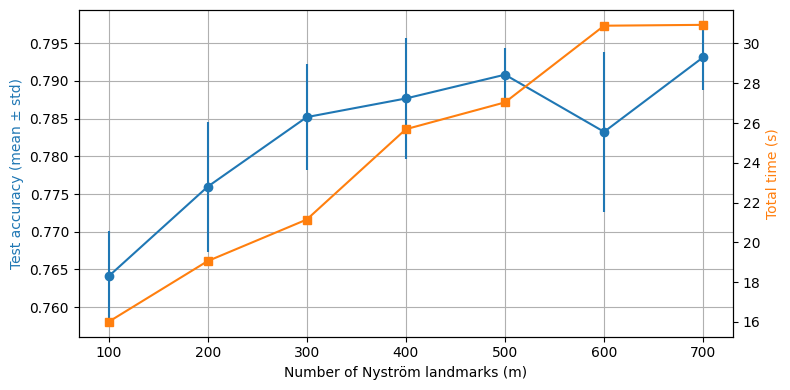

In [31]:
import numpy as np
import pandas as pd
import time
from sklearn.kernel_approximation import Nystroem
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

landmarks_list = [100, 200, 300, 400, 500, 600, 700]
n_iter = 5  # Número de repeticiones

summary = []

for m in landmarks_list:
    accs = []
    map_times = []
    cv_times = []
    best_Ks = []
    best_Cs = []
    cv_scores = []
    for it in range(n_iter):
        print(f"\n== Nyström n_components = {m} | iter {it+1}/{n_iter} ==")
        t0_map = time.time()
        feature_map = Nystroem(kernel='rbf', gamma=gamma, n_components=m, random_state=it)
        Z_train = feature_map.fit_transform(X_train)
        Z_test = feature_map.transform(X_test)
        scaler_Z = StandardScaler()
        Z_train = scaler_Z.fit_transform(Z_train)
        Z_test = scaler_Z.transform(Z_test)
        t_map = time.time() - t0_map

        FE = CCA(n_components=len(set_classes)-1)
        t0_cv = time.time()
        results = cv_feature_extraction_pipeline(
            Z_train, y_train, y_train_bin, Z_test, y_test,
            feature_extractor=FE,
            use_labels_in_fe=True,
            verbose=False
        )
        t_cv = time.time() - t0_cv

        accs.append(results['test_accuracy'])
        map_times.append(t_map)
        cv_times.append(t_cv)
        best_Ks.append(results['best_K'])
        best_Cs.append(float(results['best_C']))
        cv_scores.append(float(results['cv_score']))

    summary.append({
        'n_landmarks': m,
        'map_time_s_mean': np.mean(map_times),
        'cv_time_s_mean': np.mean(cv_times),
        'total_time_s_mean': np.mean(np.array(map_times) + np.array(cv_times)),
        'best_K_mean': np.mean(best_Ks),
        'best_C_mean': np.mean(best_Cs),
        'cv_score_mean': np.mean(cv_scores),
        'test_accuracy_mean': np.mean(accs),
        'test_accuracy_std': np.std(accs)
    })

df_summary = pd.DataFrame(summary).sort_values('n_landmarks').reset_index(drop=True)
print("\nSummary (Nyström + CCA, averaged):")
print(df_summary)

# Optional: quick plot
try:
    import matplotlib.pyplot as plt
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax2 = ax1.twinx()
    ax1.errorbar(df_summary['n_landmarks'], df_summary['test_accuracy_mean'], 
                 yerr=df_summary['test_accuracy_std'], fmt='-o', color='C0', label='test_accuracy')
    ax2.plot(df_summary['n_landmarks'], df_summary['total_time_s_mean'], '-s', color='C1', label='total_time_s')
    ax1.set_xlabel('Number of Nyström landmarks (m)')
    ax1.set_ylabel('Test accuracy (mean ± std)', color='C0')
    ax2.set_ylabel('Total time (s)', color='C1')
    ax1.grid(True)
    fig.tight_layout()
    plt.show()
except Exception:
    pass

## **4.2.3 Random Fourier Features (RBF Sampler)**

In this section, you will re-implement the **KCCA + Linear SVM** pipeline using the **RBF Sampler**, which approximates the RBF kernel using **Random Fourier Features (RFF)**. This method also reduces computational cost while providing a scalable, data-independent kernel approximation.

The RBF Sampler is based on **Bochner’s theorem**, which states that any shift-invariant kernel can be expressed as the Fourier transform of a probability distribution. For the RBF kernel:

$$
k(x_i, x_j) = \exp\left(-\gamma |x_i - x_j|^2\right),
$$

its Fourier transform is a Gaussian distribution. This makes it possible to approximate the kernel by sampling random frequencies.

The approximation proceeds as follows:

1. Sample random Fourier frequencies:

   $$
   \omega_k \sim \mathcal{N}(0, 2\gamma I), \quad k=1,\dots,m.
   $$

2. Sample random phase shifts:

   $$
   b_k \sim \text{Uniform}(0, 2\pi), \quad k=1,\dots,m.
   $$

3. Build an explicit feature map:

   $$
   \Phi(x) = \sqrt{\frac{2}{m}}
   \begin{bmatrix}
   \cos(\omega_1^\top x + b_1) \
   \vdots \
   \cos(\omega_m^\top x + b_m)
   \end{bmatrix}
   \in \mathbb{R}^{m}.
   $$

This ensures that:

$$
k(x_i, x_j) \approx \langle \Phi(x_i), \Phi(x_j) \rangle.
$$

Thus, as with the Nyström method, we avoid computing the kernel matrix and instead operate directly on **explicit low-dimensional features**.

## **Implementation of RBF Sampler in sklearn**

Scikit-learn provides the class `sklearn.kernel_approximation.RBFSampler`. This transformer receives raw data `X` and computes a **Random Fourier Feature map**:

* Draws `n_components = m` random Gaussian frequencies.
* Computes the cosine-based feature expansion described above.
* Returns the feature matrix:

$$
\mathbf{Z} = \Phi_{\text{RFF}}(X) \in \mathbb{R}^{N \times m}.
$$

This matrix satisfies the kernel approximation:

$$
K(X, X) \approx ZZ^T.
$$

Once you have the explicit features `Z`, you can plug them into:

* **KCCA (linear version)** → using the explicit RFF features
* **Linear SVM** → efficient at training and very cheap at test time

This again converts the entire kernel pipeline into a **linear pipeline**, but unlike Nyström, the approximation does **not depend on the training data**.

## **Exercise**

Use the **RBF Sampler** (Random Fourier Features) to obtain an efficient implementation of the Kernel CCA + Linear SVM pipeline. Evaluate its performance in terms of **accuracy** and **computational time** for different numbers of random features (e.g., 100, 200, …, 500), setting the RBF parameter (\gamma = 1/D), where (D) is the input dimensionality.

Finally, compare the performance of the RBF Sampler approach with:

* the **Nyström approximation** (Section 4.2.2), and
* the **full Kernel CCA** implementation.


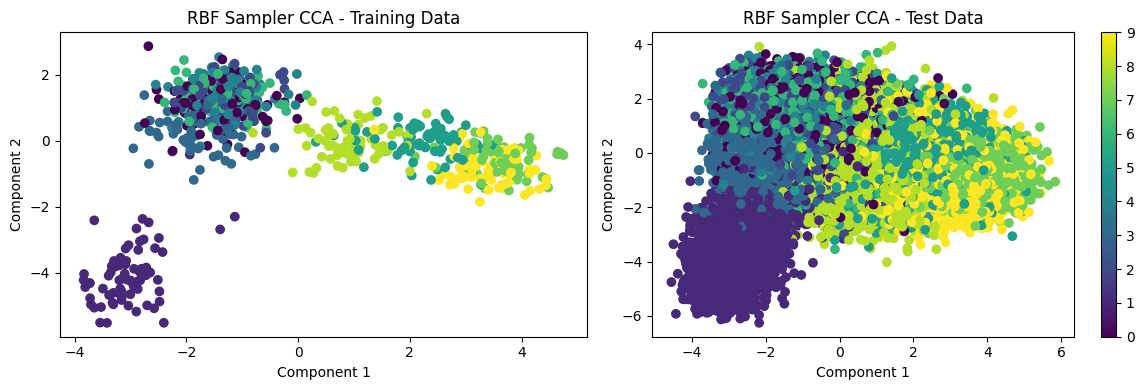

In [32]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler

n_components = 200  # Same as before, for example

feature_map = RBFSampler(
    gamma=gamma,
    n_components=n_components,
    random_state=0
)

Z_train = feature_map.fit_transform(X_train)   # (N_tr, n_components)
Z_test  = feature_map.transform(X_test)        # (N_te, n_components)

# Center the features (same normalization strategy as before)
scaler_X = StandardScaler(with_mean=True, with_std=False)

Z_train = scaler_X.fit_transform(Z_train)
Z_test  = scaler_X.transform(Z_test)

# Compute CCA with 2 components and plot data points
cca = CCA(n_components=2)
X_cca = cca.fit_transform(Z_train, y_train_bin)[0]
# Transform test data
X_cca_test = cca.transform(Z_test)

# Plot 2D projection
plot_2d_projection(X_cca, X_cca_test, y_train, y_test, method_name='RBF Sampler CCA')


== RBF Sampler n_components = 100 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 200 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 300 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 400 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 500 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 600 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

== RBF Sampler n_components = 700 ==
 iter 1/5 ... done
 iter 2/5 ... done
 iter 3/5 ... done
 iter 4/5 ... done
 iter 5/5 ... done

Summary (RBF Sampler + CCA, averaged):
   n_features  map_time_s_mea

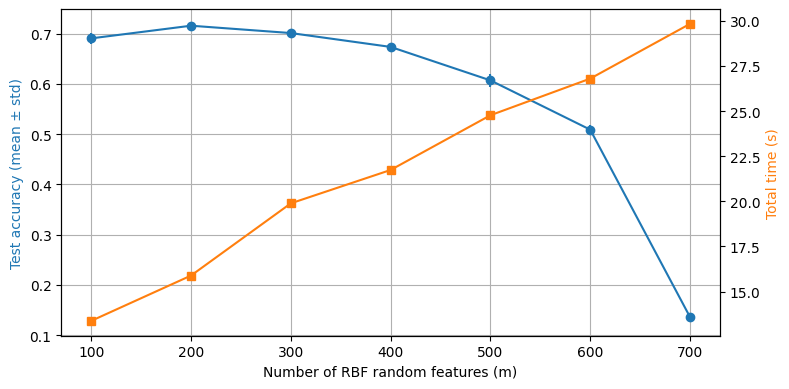

In [33]:
# RBF Sampler + CCA comparison for different numbers of random features (100,200,...,500)

from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
import time
import numpy as np
import pandas as pd

components_list = [100, 200, 300, 400, 500, 600, 700]
n_iter = 5  # number of repetitions per setting

summary = []

for m in components_list:
    print(f"\n== RBF Sampler n_components = {m} ==")
    accs = []
    map_times = []
    cv_times = []
    best_Ks = []
    best_Cs = []
    cv_scores = []

    for it in range(n_iter):
        print(f" iter {it+1}/{n_iter} ...", end='')
        # 1) compute RBF Sampler feature map
        t0_map = time.time()
        feature_map = RBFSampler(gamma=gamma, n_components=m, random_state=it)
        Z_train = feature_map.fit_transform(X_train)
        Z_test = feature_map.transform(X_test)

        scaler_Z = StandardScaler()
        Z_train = scaler_Z.fit_transform(Z_train)
        Z_test = scaler_Z.transform(Z_test)
        t_map = time.time() - t0_map

        # 2) run leakage-safe CV pipeline (timing CV + training)
        FE = CCA(n_components=len(set_classes)-1)  # will be set to best_K by the pipeline
        t0_cv = time.time()
        results = cv_feature_extraction_pipeline(
            Z_train, y_train, y_train_bin, Z_test, y_test,
            feature_extractor=FE,
            use_labels_in_fe=True,
            verbose=False  # suppress internal prints for cleaner timing loop
        )
        t_cv = time.time() - t0_cv

        map_times.append(t_map)
        cv_times.append(t_cv)
        accs.append(results['test_accuracy'])
        best_Ks.append(results['best_K'])
        best_Cs.append(float(results['best_C']))
        cv_scores.append(float(results['cv_score']))
        print(" done")

    # collect averaged results
    summary.append({
        'n_features': m,
        'map_time_s_mean': float(np.mean(map_times)),
        'map_time_s_std': float(np.std(map_times)),
        'cv_time_s_mean': float(np.mean(cv_times)),
        'cv_time_s_std': float(np.std(cv_times)),
        'total_time_s_mean': float(np.mean(np.array(map_times) + np.array(cv_times))),
        'total_time_s_std': float(np.std(np.array(map_times) + np.array(cv_times))),
        'best_K_mean': float(np.mean(best_Ks)),
        'best_K_std': float(np.std(best_Ks)),
        'best_C_mean': float(np.mean(best_Cs)),
        'cv_score_mean': float(np.mean(cv_scores)),
        'test_accuracy_mean': float(np.mean(accs)),
        'test_accuracy_std': float(np.std(accs))
    })

# Display summary as DataFrame sorted by n_features
df_summary_rbf = pd.DataFrame(summary).sort_values('n_features').reset_index(drop=True)
print("\nSummary (RBF Sampler + CCA, averaged):")
print(df_summary_rbf)

# Optional: quick plot (if matplotlib available in the notebook)
try:
    import matplotlib.pyplot as plt
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax2 = ax1.twinx()
    ax1.errorbar(df_summary_rbf['n_features'], df_summary_rbf['test_accuracy_mean'], 
                 yerr=df_summary_rbf['test_accuracy_std'], fmt='-o', color='C0', label='test_accuracy')
    ax2.plot(df_summary_rbf['n_features'], df_summary_rbf['total_time_s_mean'], '-s', color='C1', label='total_time_s')
    ax1.set_xlabel('Number of RBF random features (m)')
    ax1.set_ylabel('Test accuracy (mean ± std)', color='C0')
    ax2.set_ylabel('Total time (s)', color='C1')
    ax1.grid(True)
    fig.tight_layout()
    plt.show()
except Exception:
    pass
